In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import data as dt, models as md, backtest as bt
output_dir = Path("../Outputs")
output_dir.mkdir(exist_ok = True)
print("Imports OK")

Imports OK


In [3]:
stocks_returns, macro_returns, prices = dt.load_data()

print("Computing simple residuals ...")
factor_returns = macro_returns[['SPY', 'IYT']]
residuals = md.compute_simple_residuals(stocks_returns, factor_returns, window = 90)
zscores = md.compute_rolling_zscore(residuals, window = 45)

print("Ready. Residuals shape:", residuals.shape)

Stocks: 20 tickers
Macro columns: ['SPY', 'IYT', 'Brent', 'VIX']
Dates: 2336 trading days
Range: 2017-04-07 -> 2026-07-30
Computing simple residuals ...
Ready. Residuals shape: (2336, 20)


In [4]:
signals = bt.generate_signals(zscores,
                              entry = bt.entry_threshold,
                              exit_ = bt.exit_threshold,
                              top_n = bt.top_n,
                              min_hold = bt.min_hold_days,
                              momentum = False,
                             )
active = (signals != 0).any(axis=1)
print(f"Active days: {active.sum()} / {len(signals)} ({active.mean():.1%})")
print(f"\nSignal value counts:")
print(signals.stack().value_counts())
signals.head()

Active days: 472 / 2336 (20.2%)

Signal value counts:
 0.0    46026
 1.0      366
-1.0      328
Name: count, dtype: int64


,DAL,UAL,AAL,LUV,ALK,JBLU,UNP,CSX,NSC,CP,CNI,UPS,FDX,JBHT,ODFL,KNX,SAIA,SNDR,CHRW,EXPD
Date,,,,,,,,,,,,,,,,,,,,
2017-04-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-04-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-04-11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-04-12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-04-13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
holding_periods = []
for col in signals.columns:
    s = signals[col]
    in_pos = False
    count = 0
    for val in s:
        if val != 0:
            count += 1
            in_pos = True
        elif in_pos:
            holding_periods.append(count)
            count = 0
            in_pos = False
    if in_pos and count > 0:
        holding_periods.append(count)

if len(holding_periods) == 0:
    print("No completed positions found.")
    print("Either no signals fired or all positions still open.")
else:
    holding_s = pd.Series(holding_periods)
    print(f"Holding period distribution:")
    print(f"Min: {holding_s.min():.0f} days (should be ≥ 5)")
    print(f"Median: {holding_s.median():.0f} days")
    print(f"Mean: {holding_s.mean():.1f} days")
    print(f"Max: {holding_s.max():.0f} days")
    print(f"Positions shorter than 5 days: {(holding_s < 5).sum()}")

Holding period distribution:
Min: 1 days (should be ≥ 5)
Median: 6 days
Mean: 6.3 days
Max: 16 days
Positions shorter than 5 days: 1


In [6]:
active_days = signals[signals.abs().sum(axis = 1) > 0]
positions_per_day = signals.abs().sum(axis = 1)
print(f"Position count distribution:")
print(positions_per_day[positions_per_day > 0].value_counts().sort_index())

Position count distribution:
1.0    322
2.0     97
3.0     42
4.0      5
5.0      4
6.0      2
Name: count, dtype: int64


In [7]:
positions_raw = bt.construct_portfolio(signals, zscores = zscores, residuals = residuals)
positions = bt.apply_macro_regime_filter(positions_raw, macro_returns, vix_window = 90, brent_window = 90)
print(f"Gross exposure: {positions.abs().sum(axis = 1).mean():.3f}")
print(f"Net exposure mean: {positions.sum(axis = 1).abs().mean():.6f}")

Gross exposure: 0.038
Net exposure mean: 0.026516


In [8]:
net_returns, trades = bt.compute_portfolio_returns(positions, stocks_returns)
print(f"Ann. turnover: {trades['turnover'].mean()*252:.2f}")
print(f"Ann. cost drag: {trades['transaction_cost'].mean()*252:.2%}")
print(f"Active days: {(net_returns != 0).sum()}")
trades.head()

Ann. turnover: 2.61
Ann. cost drag: 0.26%
Active days: 518


,gross_return,turnover,transaction_cost,net_return,n_longs,n_shorts,gross_exposure
Date,,,,,,,
2017-04-07,0.0,0.0,0.0,0.0,0,0,0.0
2017-04-10,0.0,0.0,0.0,0.0,0,0,0.0
2017-04-11,0.0,0.0,0.0,0.0,0,0,0.0
2017-04-12,0.0,0.0,0.0,0.0,0,0,0.0
2017-04-13,0.0,0.0,0.0,0.0,0,0,0.0


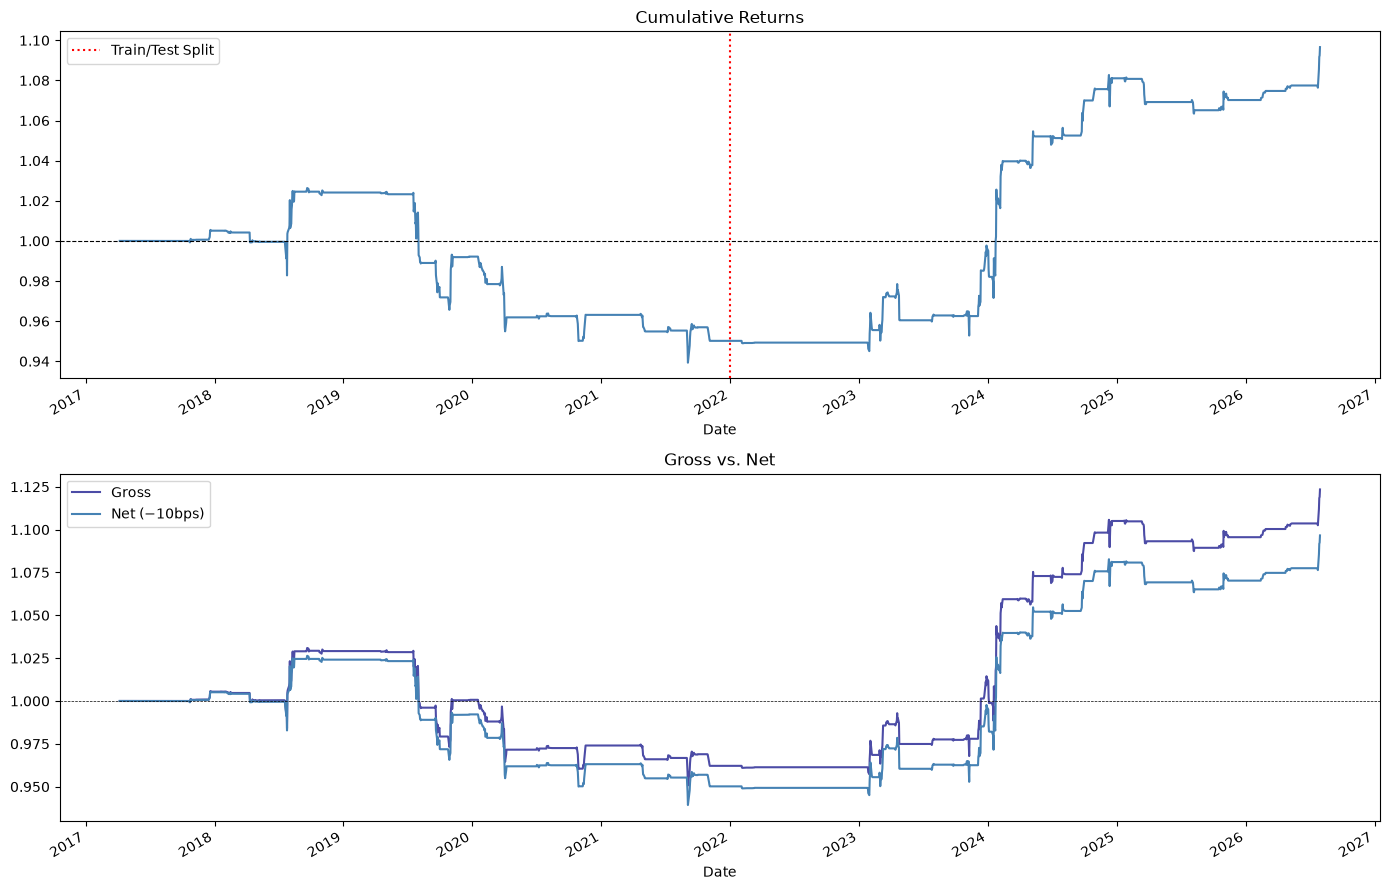

In [9]:
fig, axes = plt.subplots(2, 1, figsize = (14, 9))
(1 + net_returns).cumprod().plot(ax = axes[0], color = 'steelblue', linewidth = 1.5)
axes[0].axhline(1.0, color = 'black', linestyle = '--', linewidth = 0.8)

if 'dt' in globals() and hasattr(dt, 'test_start'):
    axes[0].axvline(pd.Timestamp(dt.test_start), color = 'red',
                    linestyle = ':', label = 'Train/Test Split')
title = "Cumulative Returns"
if 'perf' in globals():
    title += f" | Sharpe: {perf['sharpe_ratio']:.3f} | MDD: {perf['max_drawdown']:.1%}"
axes[0].set_title(title)
axes[0].legend()

(1 + trades['gross_return']).cumprod().plot(ax = axes[1], label = 'Gross', alpha = 0.7, color = 'navy')
(1 + trades['net_return']).cumprod().plot(ax = axes[1], label = 'Net (−10bps)', color = 'steelblue', linewidth = 1.5)
axes[1].axhline(1.0, color = 'black', linestyle = '--', linewidth = 0.5)
axes[1].legend()
axes[1].set_title("Gross vs. Net")

plt.tight_layout()
plt.show()

In [10]:
diag = bt.macro_regime_diagnostics(net_returns, macro_returns)
print("Sharpe by Macro Regime Quartile:")
print(diag.to_string())

Sharpe by Macro Regime Quartile:
          Q1     Q2     Q3     Q4
VIX    1.556 -0.955 -0.352 -0.114
Brent -0.403 -0.475  0.751  1.256


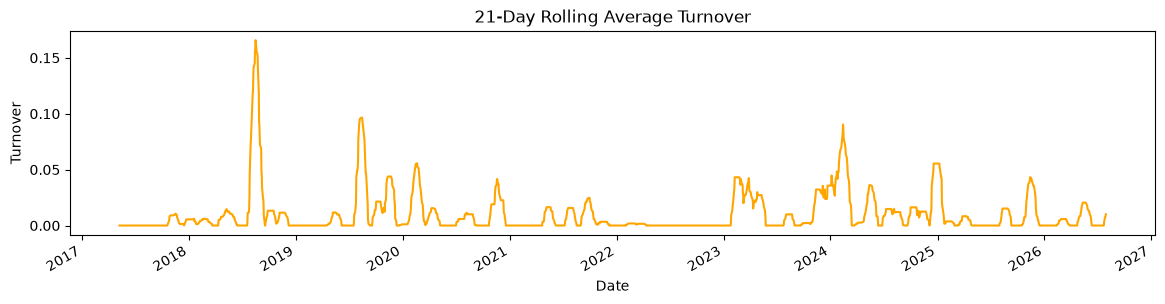

Avg daily turnover: 0.0104
Avg annual turnover: 2.61x


In [11]:
trades['turnover'].rolling(21).mean().plot(figsize = (14, 3), color = 'orange', title = "21-Day Rolling Average Turnover")
plt.ylabel("Turnover")
plt.show()
print(f"Avg daily turnover: {trades['turnover'].mean():.4f}")
print(f"Avg annual turnover: {trades['turnover'].mean()*252:.2f}x")

In [12]:
if 'perf' not in globals() or perf is None:
    perf = bt.compute_performance(net_returns, trades, macro_returns)
output_dir = Path("Outputs")
output_dir.mkdir(exist_ok = True)
net_returns.to_frame("net_return").to_csv(output_dir / "net_returns.csv")
perf.to_frame("strategy").to_csv(output_dir / "performance.csv")
positions.to_csv(output_dir / "signals.csv")
trades.to_csv(output_dir / "trades.csv")
print("Saved successfully.")
print(perf[['annualized_returns', 'sharpe_ratio', 'ann_turnover', 'max_drawdown']])

Saved successfully.
annualized_returns    0.0103
sharpe_ratio          0.3700
ann_turnover          2.6090
max_drawdown         -0.0848
dtype: float64


True new entries found: 111

=== Clean Trade Statistics ===
Win rate 5-day : 51.8%
Win rate 10-day: 61.8%
Avg PnL 5-day  : 0.00263
Avg PnL 10-day : 0.00872

By direction:
            pnl_5d  pnl_10d
direction                  
Long       0.00358  0.00880
Short      0.00164  0.00865


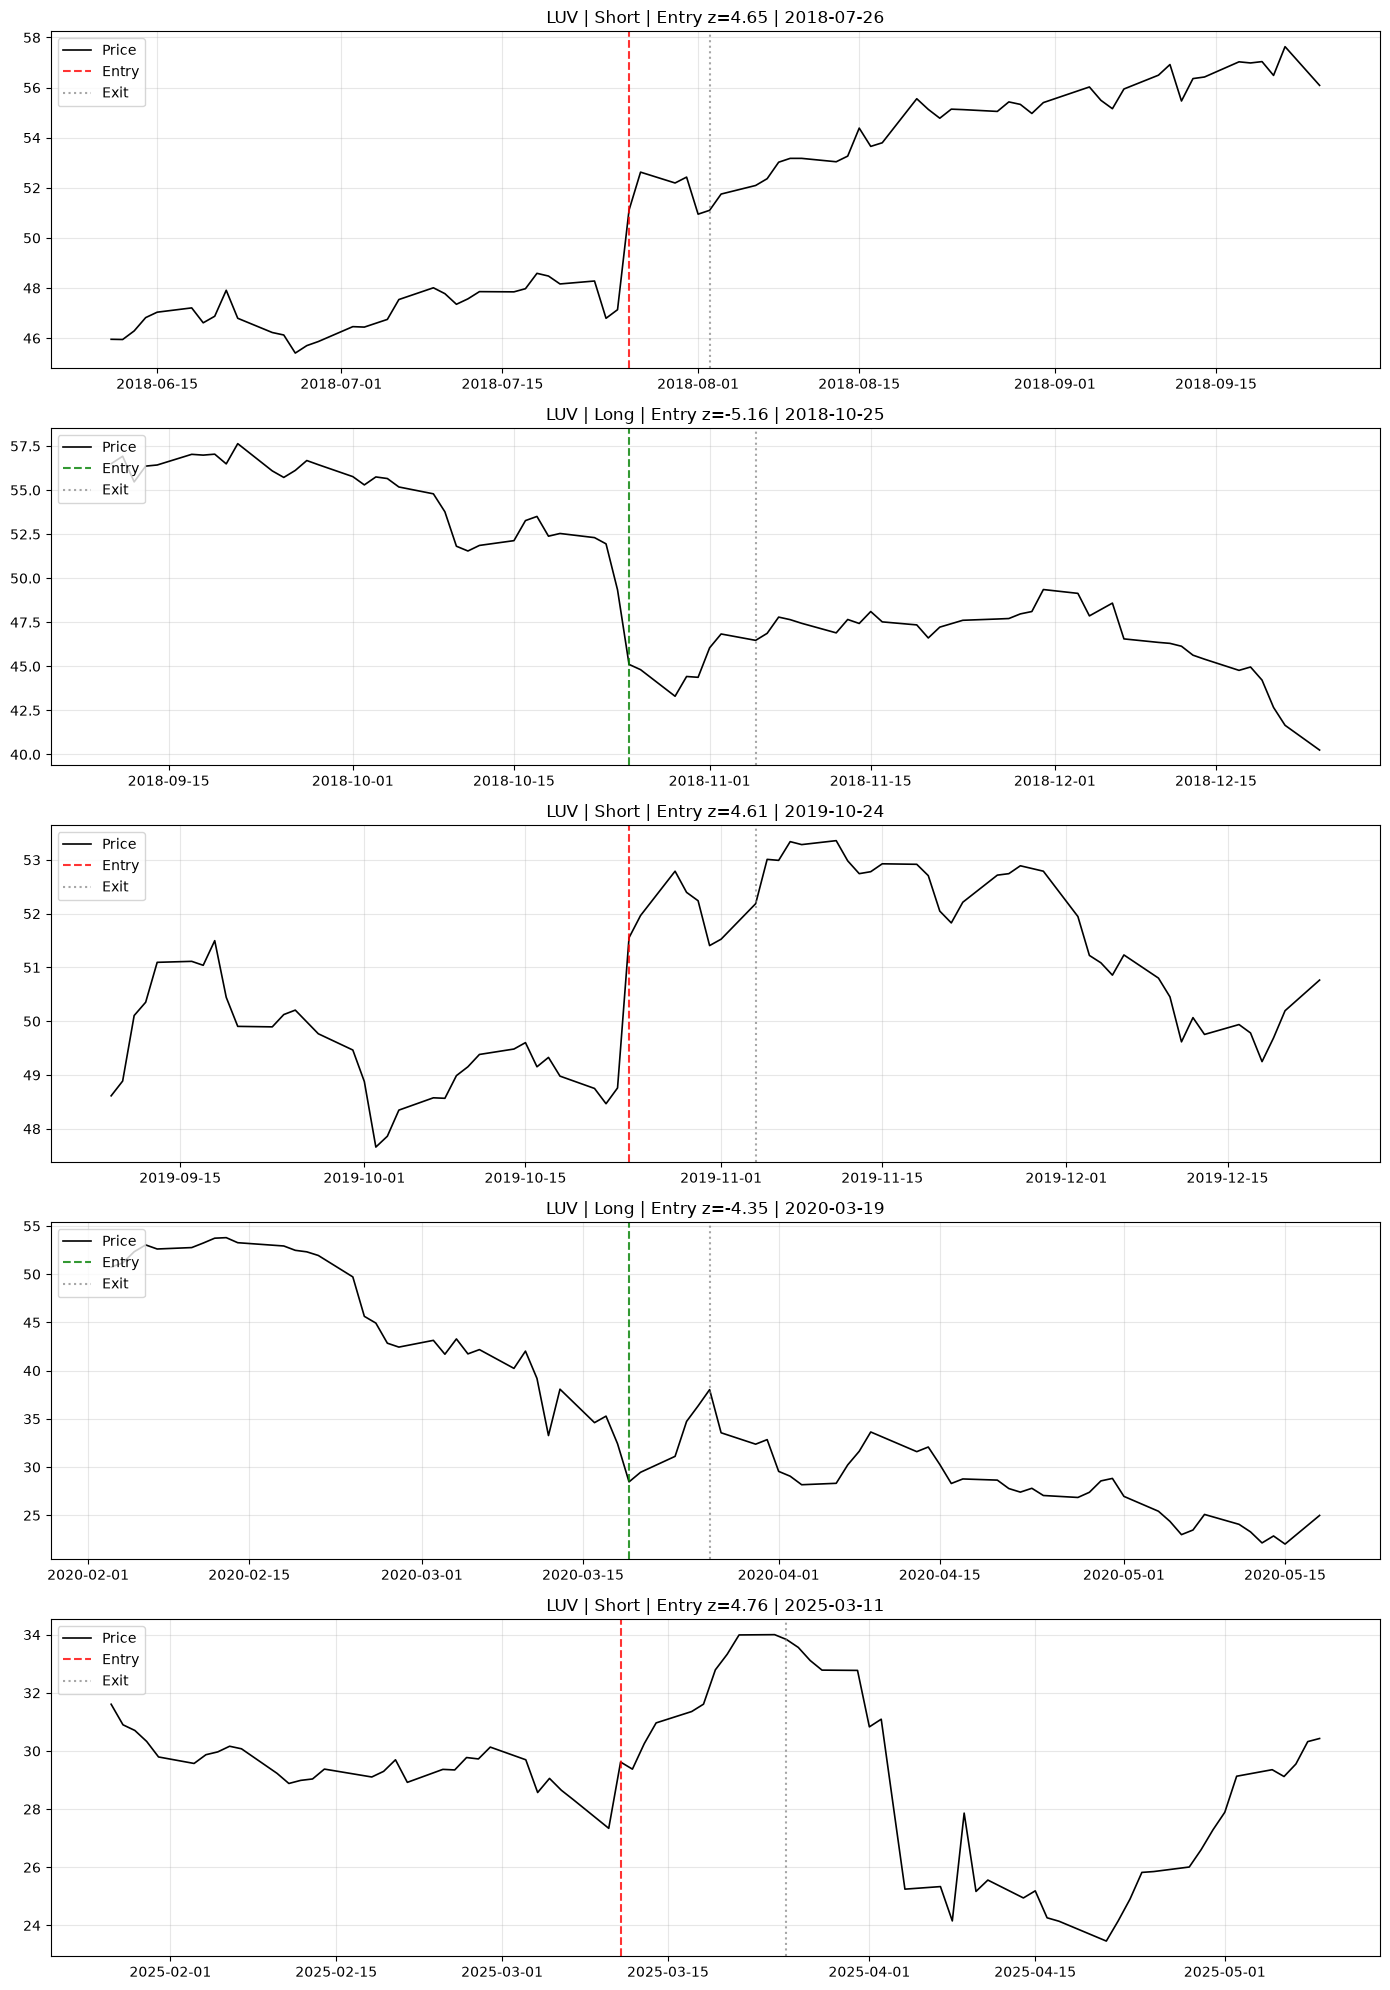

In [13]:
import matplotlib.pyplot as plt

def analyze_and_plot_trades(signals, zscores, prices, ticker='LUV', max_plots=18):
    """
    Clean diagnostic:
    - Only counts true new entries (signal crosses from 0 to ±1)
    - Shows average PnL after entry
    - Plots price + entry/exit markers for the chosen ticker
    """
    
    # ---------- 1. Find true entries ----------
    entries = []
    prev = pd.Series(0, index=signals.columns)
    
    for date in signals.index:
        curr = signals.loc[date]
        for t in signals.columns:
            if prev[t] == 0 and curr[t] != 0:
                entries.append({
                    'date': date,
                    'ticker': t,
                    'direction': 1 if curr[t] > 0 else -1,
                    'entry_z': zscores.loc[date, t]
                })
        prev = curr.copy()
    
    entry_df = pd.DataFrame(entries)
    print(f"True new entries found: {len(entry_df)}")
    
    if len(entry_df) == 0:
        print("No true entries found.")
        return
    
    # ---------- 2. Calculate forward residual PnL ----------
    results = []
    for _, row in entry_df.iterrows():
        date = row['date']
        t = row['ticker']
        direction = row['direction']
        
        future = residuals[t].loc[date:].iloc[1:11]  # next 10 days
        if len(future) < 5:
            continue
            
        ret_5 = future.iloc[:5].sum()
        ret_10 = future.iloc[:10].sum()
        
        pnl_5 = ret_5 * direction
        pnl_10 = ret_10 * direction
        
        results.append({
            'date': date,
            'ticker': t,
            'direction': 'Long' if direction > 0 else 'Short',
            'entry_z': round(row['entry_z'], 2),
            'pnl_5d': pnl_5,
            'pnl_10d': pnl_10
        })
    
    res_df = pd.DataFrame(results)
    
    print("\n=== Clean Trade Statistics ===")
    print(f"Win rate 5-day : { (res_df['pnl_5d'] > 0).mean():.1%}")
    print(f"Win rate 10-day: { (res_df['pnl_10d'] > 0).mean():.1%}")
    print(f"Avg PnL 5-day  : {res_df['pnl_5d'].mean():.5f}")
    print(f"Avg PnL 10-day : {res_df['pnl_10d'].mean():.5f}")
    print("\nBy direction:")
    print(res_df.groupby('direction')[['pnl_5d', 'pnl_10d']].mean().round(5))
    
    # ---------- 3. Visualization for one ticker ----------
    if ticker not in prices.columns:
        print(f"\n{ticker} not found in prices")
        return
    
    t_entries = entry_df[entry_df['ticker'] == ticker].head(max_plots)
    
    if len(t_entries) == 0:
        print(f"No entries found for {ticker}")
        return
    
    fig, axes = plt.subplots(len(t_entries), 1, figsize=(14, 4*len(t_entries)), sharex=False)
    if len(t_entries) == 1:
        axes = [axes]
    
    for ax, (_, row) in zip(axes, t_entries.iterrows()):
        date = row['date']
        direction = row['direction']
        
        # Plot window: 30 days before to 40 days after
        start = date - pd.Timedelta(days=45)
        end = date + pd.Timedelta(days=60)
        
        price_slice = prices[ticker].loc[start:end]
        signal_slice = signals[ticker].loc[start:end]
        
        ax.plot(price_slice.index, price_slice.values, color='black', linewidth=1.2, label='Price')
        
        # Entry marker
        color = 'green' if direction > 0 else 'red'
        ax.axvline(date, color=color, linestyle='--', alpha=0.8, label='Entry')
        
        # Exit markers (when signal returns to 0)
        exits = signal_slice[signal_slice == 0].loc[date:]
        if len(exits) > 0:
            exit_date = exits.index[0]
            ax.axvline(exit_date, color='gray', linestyle=':', alpha=0.7, label='Exit')
        
        ax.set_title(f"{ticker} | {'Long' if direction > 0 else 'Short'} | Entry z={row['entry_z']:.2f} | {date.date()}")
        ax.legend(loc='upper left')
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Run it
analyze_and_plot_trades(signals, zscores, prices, ticker='LUV', max_plots=18)

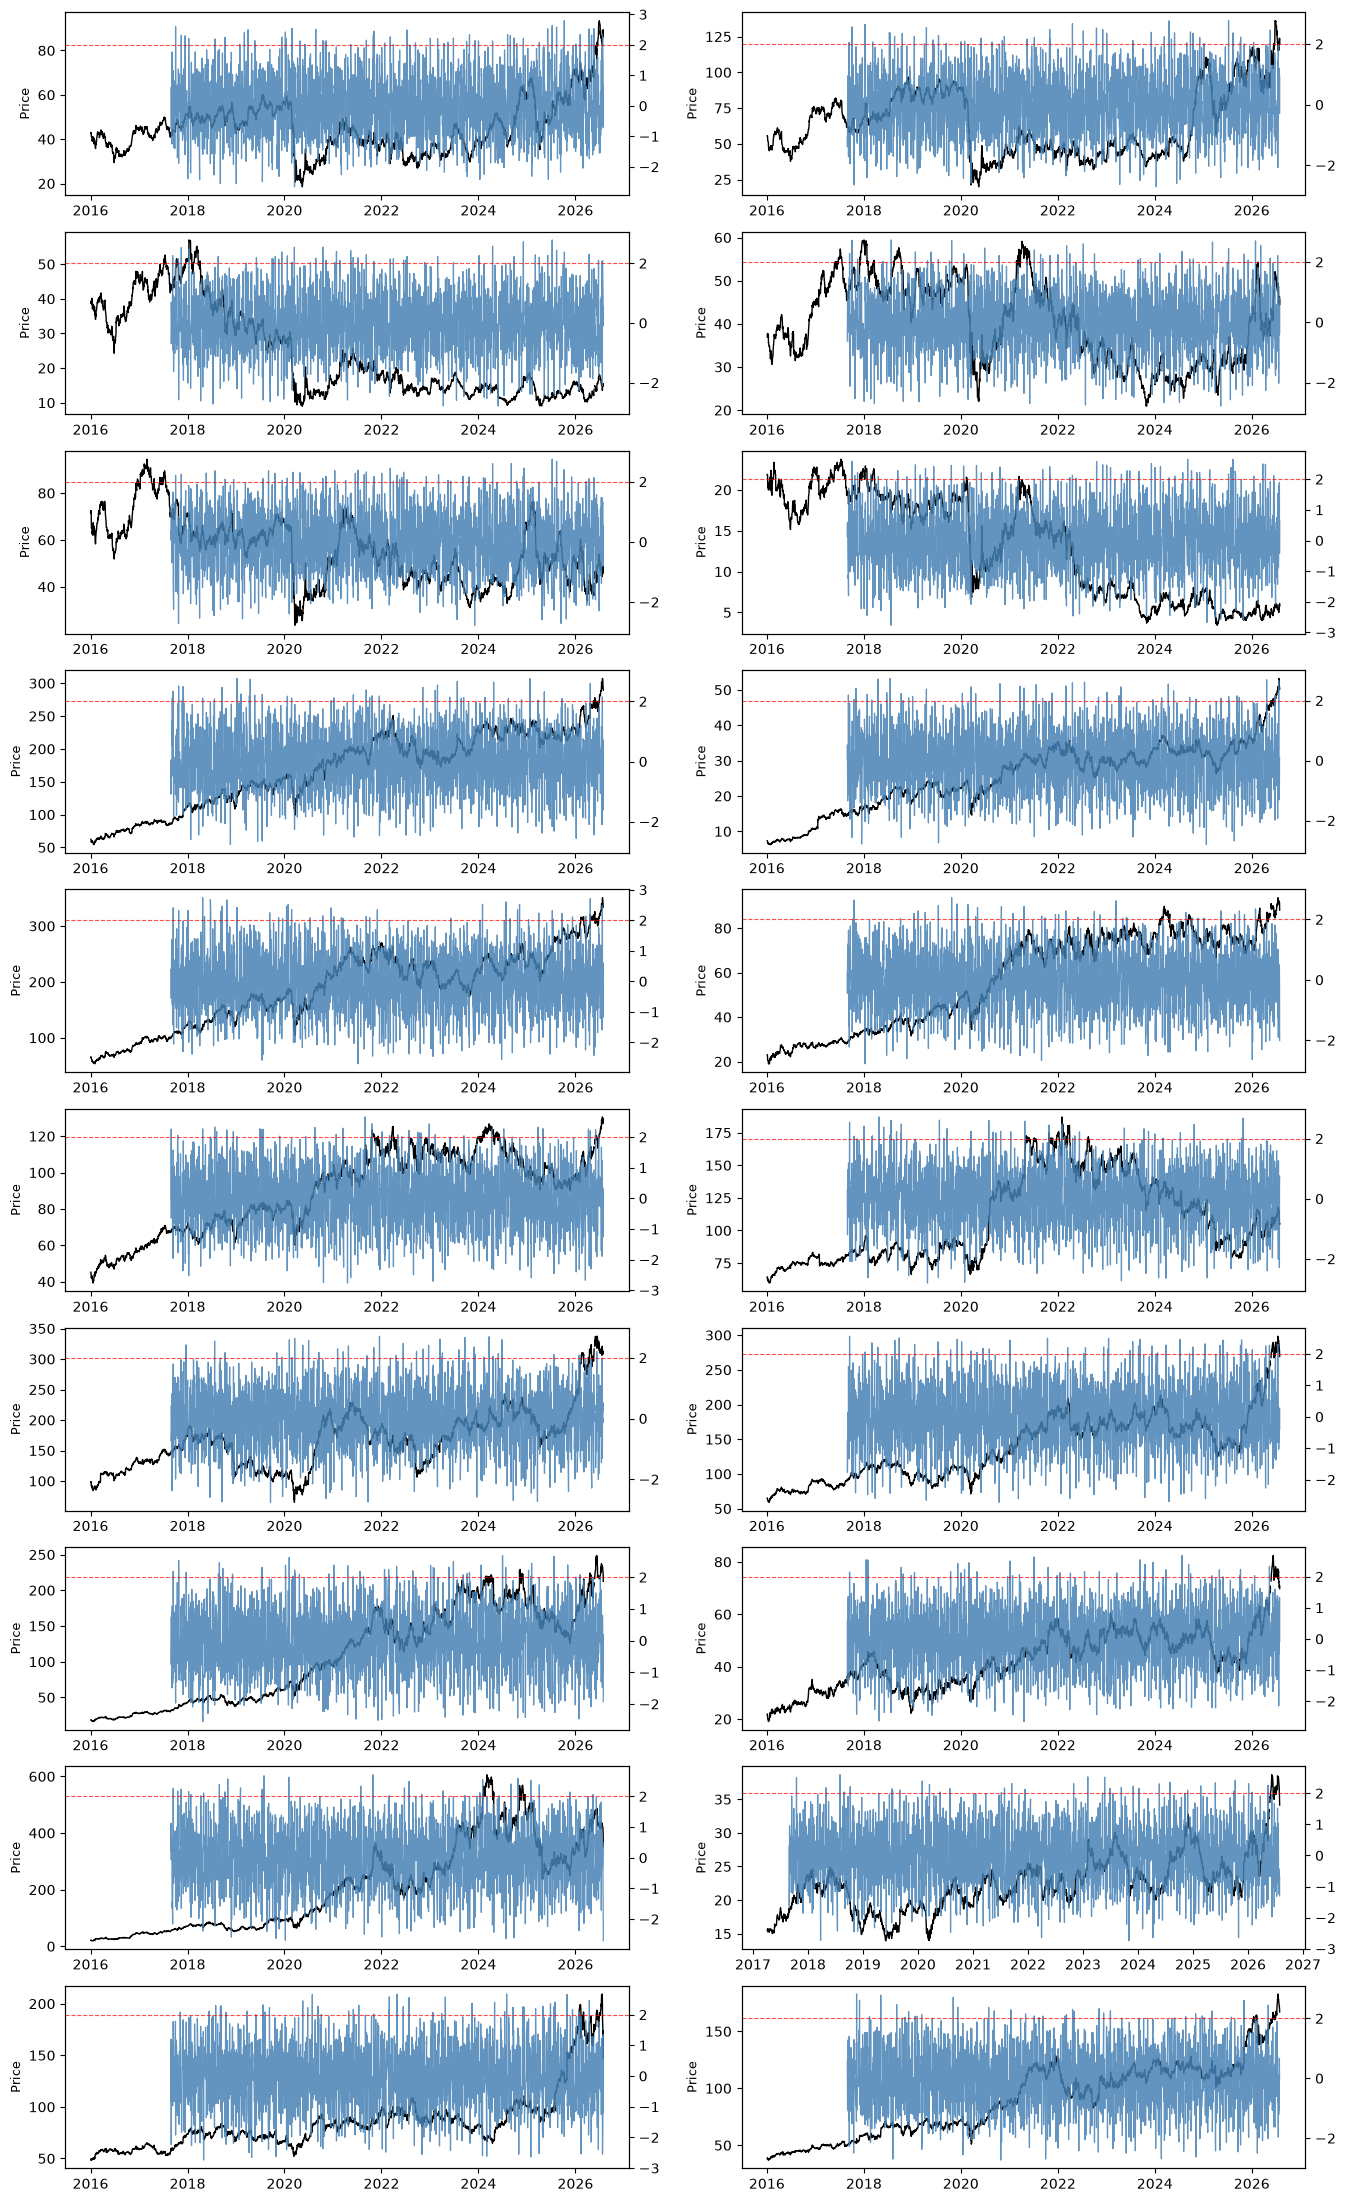

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Compute 45-day residual z-scores
z = md.compute_rolling_zscore(residuals, window=10)

tickers = list(z.columns)
n = len(tickers)

fig, axes = plt.subplots(nrows=10, ncols=2, figsize=(16, 28), sharex=False)
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    
    # Price on left y-axis
    color_price = 'black'
    ax.plot(prices[ticker].loc['2016':], color=color_price, linewidth=1.0, label='Price')
    ax.set_ylabel('Price', color=color_price, fontsize=9)
    ax.tick_params(axis='y', labelcolor=color_price)
    
    # Z-score on right y-axis
    ax2 = ax.twinx()
    color_z = 'steelblue'
    ax2.plot(z[ticker].loc['2016':], color=color_z, linewidth=0.9, alpha=0.85, label='Z-Score')
    ax2.axhline(2.0, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
   